# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [47]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress

# Impor the OpenWeatherMap API key
from api_keys import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

### Generate the Cities List by Using the `citipy` Library

In [50]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name

    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 610


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [10]:
# Set the API base URL
url = "http://api.openweathermap.org/data/2.5/weather?units=Metric&APPID=" + weather_api_key

# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger
print("Beginning Data Retrieval     ")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):

    # Group cities in sets of 50 for logging purposes
    if (i % 50 == 0 and i >= 50):
        set_count += 1
        record_count = 0

    # Create endpoint URL with each city
    city_url = url+'&q='+city

    # Log the url, record, and set numbers
    print("Processing Record %s of Set %s | %s" % (record_count, set_count, city))

    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Parse the JSON and retrieve data
        city_weather = requests.get(city_url).json()

        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = city_weather["dt"]

        # Append the City information into city_data list
        city_data.append({"City": city,
                          "Lat": city_lat,
                          "Lng": city_lng,
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})

    # If an error is experienced, skip the city
    except:
        print("City not found. Skipping...")
        pass

    # pause to avoid rate limiting
    time.sleep(1)

# Indicate that Data Loading is complete
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval     
-----------------------------
Processing Record 1 of Set 1 | nar'yan-mar
Processing Record 2 of Set 1 | west island
Processing Record 3 of Set 1 | cockburn town
Processing Record 4 of Set 1 | kabalo
Processing Record 5 of Set 1 | bethel
Processing Record 6 of Set 1 | hermanus
Processing Record 7 of Set 1 | chifeng
Processing Record 8 of Set 1 | adamstown
Processing Record 9 of Set 1 | caleta de carquin
Processing Record 10 of Set 1 | borkum
Processing Record 11 of Set 1 | menaka
Processing Record 12 of Set 1 | lospalos
Processing Record 13 of Set 1 | papatowai
Processing Record 14 of Set 1 | mo i rana
Processing Record 15 of Set 1 | al jawf
Processing Record 16 of Set 1 | edinburgh of the seven seas
Processing Record 17 of Set 1 | whitehorse
Processing Record 18 of Set 1 | puerto natales
Processing Record 19 of Set 1 | kodiak
Processing Record 20 of Set 1 | port-aux-francais
Processing Record 21 of Set 1 | stanley
Processing Record 22 of Set 1 | longyearby

In [13]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
city_data_df.count()

City          523
Lat           523
Lng           523
Max Temp      523
Humidity      523
Cloudiness    523
Wind Speed    523
Country       523
Date          523
dtype: int64

In [15]:
# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,nar'yan-mar,67.6713,53.0870,-7.65,97,97,1.77,RU,1739330251
1,west island,-12.1568,96.8225,28.99,84,75,7.72,CC,1739330471
2,cockburn town,21.4612,-71.1419,25.33,80,5,9.95,TC,1739330472
3,kabalo,-6.0500,26.9167,20.78,97,100,0.69,CD,1739330473
4,bethel,41.3712,-73.4140,-0.55,70,100,0.45,US,1739330442


In [17]:
# Export the City_Data into a csv
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [19]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,nar'yan-mar,67.6713,53.0870,-7.65,97,97,1.77,RU,1739330251
1,west island,-12.1568,96.8225,28.99,84,75,7.72,CC,1739330471
2,cockburn town,21.4612,-71.1419,25.33,80,5,9.95,TC,1739330472
3,kabalo,-6.0500,26.9167,20.78,97,100,0.69,CD,1739330473
4,bethel,41.3712,-73.4140,-0.55,70,100,0.45,US,1739330442


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

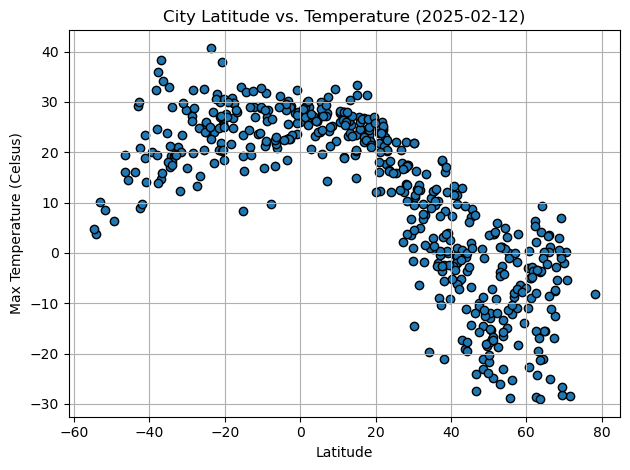

In [22]:
# Build scatter plot for latitude vs. temperature
plt.scatter(city_data_df["Lat"], city_data_df["Max Temp"], edgecolors="k")


#Format date
date = pd.Timestamp.now()
date = date.strftime("%Y-%m-%d")

# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Max Temperature (Celsus)")
plt.title(f"City Latitude vs. Temperature ({date})")
plt.grid(True) 
plt.tight_layout()

# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()

#### Latitude Vs. Humidity

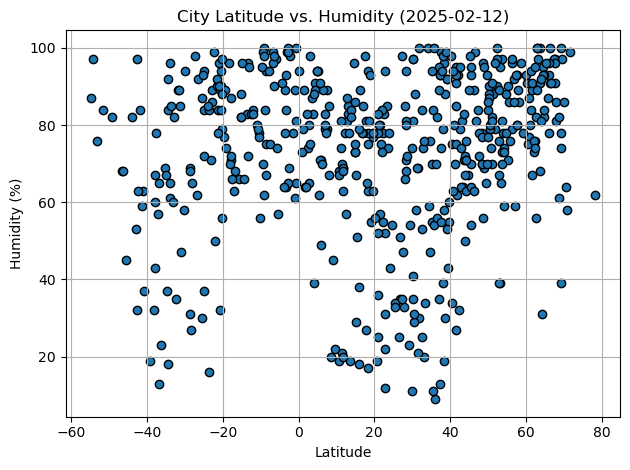

In [25]:
# Build the scatter plots for latitude vs. humidity
plt.scatter(city_data_df["Lat"], city_data_df["Humidity"], edgecolors="k")

#Format date
date = pd.Timestamp.now()
date = date.strftime("%Y-%m-%d")


# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Humidity (%)")
plt.title(f"City Latitude vs. Humidity ({date})")
plt.grid(True) 
plt.tight_layout()

# Save the figure
plt.savefig("output_data/Fig2.png")

# Show plot
plt.show()

#### Latitude Vs. Cloudiness

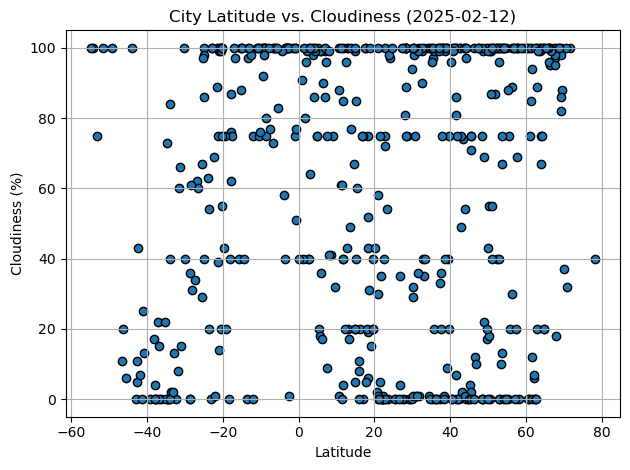

In [28]:
# Build the scatter plots for latitude vs. cloudiness
plt.scatter(city_data_df["Lat"], city_data_df["Cloudiness"], edgecolors="k")

#Format date
date = pd.Timestamp.now()
date = date.strftime("%Y-%m-%d")

# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Cloudiness (%)")
plt.title(f"City Latitude vs. Cloudiness ({date})")
plt.grid(True) 
plt.tight_layout()

# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

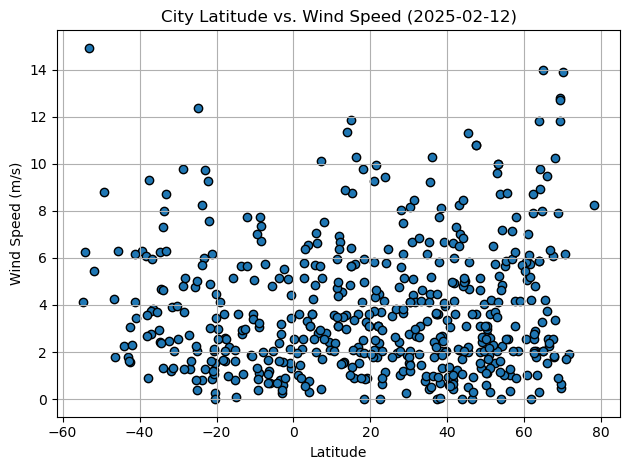

In [31]:
# Build the scatter plots for latitude vs. wind speed
plt.scatter(city_data_df["Lat"], city_data_df["Wind Speed"], edgecolors="k")

#Format date
date = pd.Timestamp.now()
date = date.strftime("%Y-%m-%d")


# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Wind Speed (m/s)")
plt.title(f"City Latitude vs. Wind Speed ({date})")
plt.grid(True) 
plt.tight_layout()

# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [176]:
# Define a function to create Linear Regression plots
from scipy.stats import linregress
from scipy import stats

def plot_linear_regression(data, x_col, y_col, title = "Linear Regression Plot"):
 
    # Extracting the x and y values
    X = data[x_col]
    y = data[y_col]

    # Performing linear regression using scipy.stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)

    # Predicting y values
    y_fit = slope * X + intercept

    # Plotting the data points
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, label='Data points')

    # Plotting the regression line
    plt.plot(X, y_fit, color='red', linestyle='--', label='Regression line')

    # Annotate the plot with the regression equation
    line_eq = f"y = {slope:.2f}x + {intercept:.2f}"
    plt.annotate(line_eq, xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, color="red", ha='left', va='top')
    print(linregress(X, y))

    # Adding title and labels
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.show()
    

In [146]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df = city_data_df.loc[pd.to_numeric(city_data_df["Lat"]) >= 0, :]

# Display sample data
northern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,nar'yan-mar,67.6713,53.0870,-7.65,97,97,1.77,RU,1739330251
2,cockburn town,21.4612,-71.1419,25.33,80,5,9.95,TC,1739330472
4,bethel,41.3712,-73.4140,-0.55,70,100,0.45,US,1739330442
6,chifeng,42.2683,118.9636,-5.49,32,0,7.32,CN,1739330476
9,borkum,53.5809,6.6915,1.15,97,100,8.72,DE,1739330211


In [148]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df=city_data_df.loc[pd.to_numeric(city_data_df["Lat"]) < 0, :]

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
1,west island,-12.1568,96.8225,28.99,84,75,7.72,CC,1739330471
3,kabalo,-6.0500,26.9167,20.78,97,100,0.69,CD,1739330473
5,hermanus,-34.4187,19.2345,19.33,84,0,4.66,ZA,1739330475
7,adamstown,-25.0660,-130.1015,25.76,72,86,0.37,PN,1739330477
8,caleta de carquin,-11.0925,-77.6267,23.57,80,100,1.88,PE,1739330478


###  Temperature vs. Latitude Linear Regression Plot

LinregressResult(slope=-0.6839197383604898, intercept=31.009516632172883, rvalue=-0.82920169887013, pvalue=1.6834804995895238e-95, stderr=0.02396716490437336, intercept_stderr=0.9977348108941976)


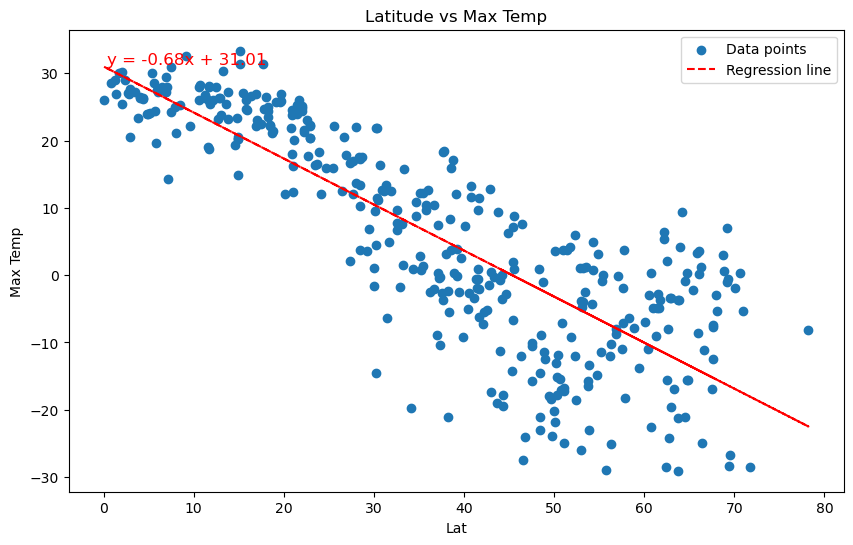

In [180]:
# Linear regression on Northern Hemisphere
from scipy import stats

plot_linear_regression(northern_hemi_df, "Lat", "Max Temp", title = "Latitude vs Max Temp")

LinregressResult(slope=-0.6839197383604898, intercept=31.009516632172883, rvalue=-0.82920169887013, pvalue=1.6834804995895238e-95, stderr=0.02396716490437336, intercept_stderr=0.9977348108941976)

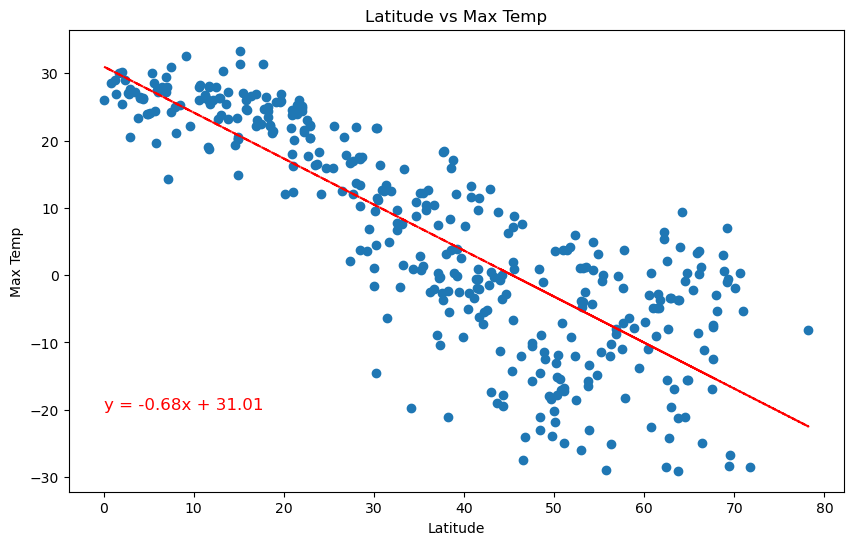

In [90]:
# Linear regression on Northern Hemisphere without function

X = northern_hemi_df["Lat"]
y = northern_hemi_df["Max Temp"]
slope = linregress(X, y)
(slope, intercept, r_value, p_value, std_err) = linregress(X, y)
regress_values = X * slope + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"

#Plot values
plt.figure(figsize=(10, 6))
plt.scatter(X, y) 
plt.plot(X, regress_values, color = "red", linestyle = "--")
plt.annotate(line_eq,(0,-20),fontsize=12,color="red")
plt.xlabel("Latitude")
plt.ylabel("Max Temp")
plt.title("Latitude vs Max Temp")

linregress(X, y)


LinregressResult(slope=0.19783860629068542, intercept=28.053603864728732, rvalue=0.4010785649545663, pvalue=3.3342528055638e-07, stderr=0.037017290741330255, intercept_stderr=0.9566438095811052)


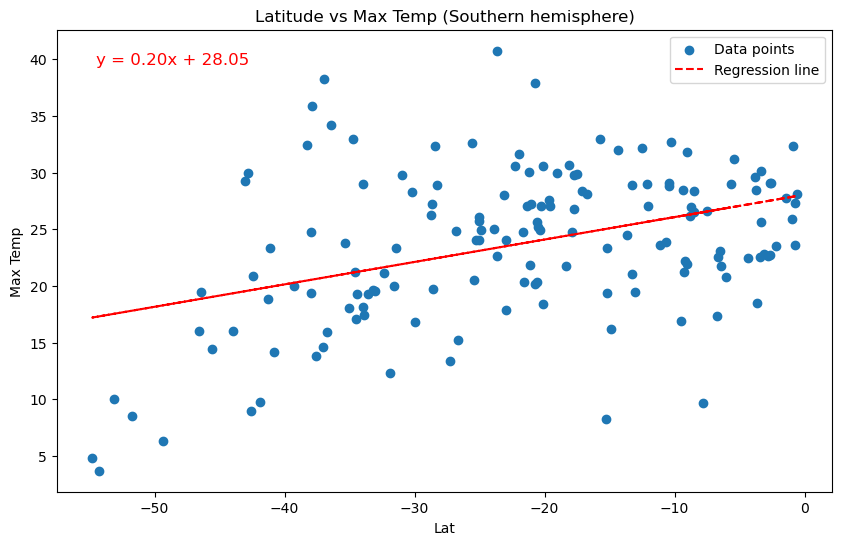

In [178]:
# Linear regression on Southern Hemisphere

plot_linear_regression(southern_hemi_df, "Lat", "Max Temp", title = "Latitude vs Max Temp (Southern hemisphere)")


**Discussion about the linear relationship:** The correlation of latitude to maximum temperature in northern hemisphere shows strong negative association with correlation value (R=-0.84), however, positively correlates in southern hemisphere with R=0.401 with very good pValues.

### Humidity vs. Latitude Linear Regression Plot

LinregressResult(slope=0.283328568947154, intercept=61.92871956357948, rvalue=0.2536395102147452, pvalue=7.164590041397348e-07, stderr=0.05617372918716952, intercept_stderr=2.338469539113301)


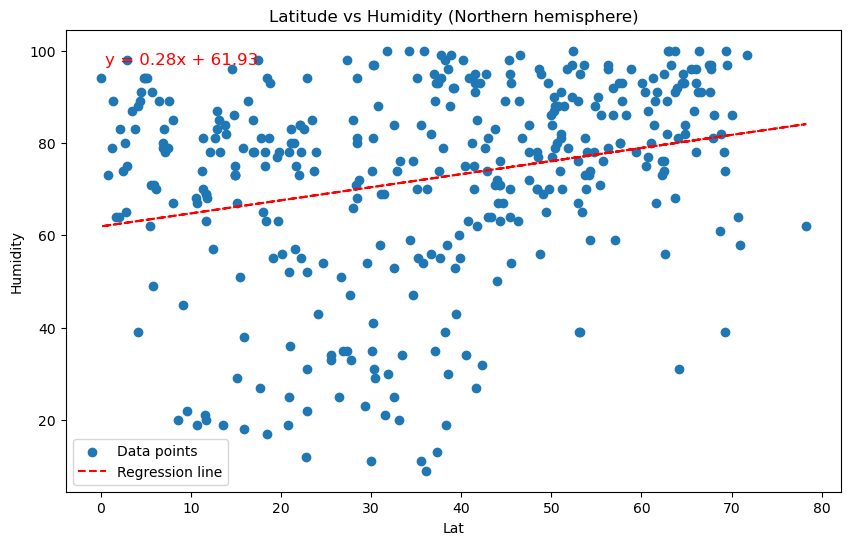

In [182]:
# Northern Hemisphere
plot_linear_regression(northern_hemi_df, "Lat", "Humidity", title = "Latitude vs Humidity (Northern hemisphere)")


LinregressResult(slope=0.5191844015113881, intercept=85.85774590609101, rvalue=0.34537275245837834, pvalue=1.4045220015118183e-05, stderr=0.11557363767494915, intercept_stderr=2.9867881419280904)


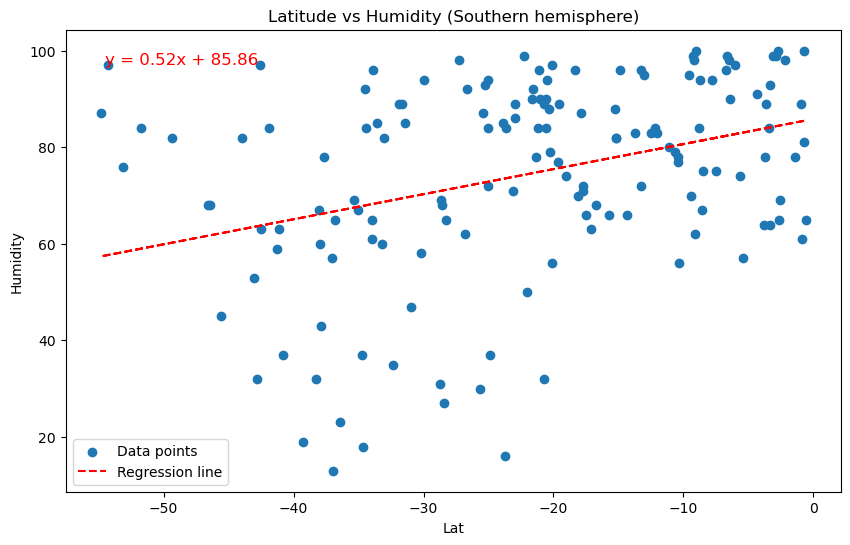

In [184]:
# Southern Hemisphere

plot_linear_regression(southern_hemi_df, "Lat", "Humidity", title = "Latitude vs Humidity (Southern hemisphere)")


**Discussion about the linear relationship:** The correlation of latitude to humidity in both northern and southern hemisphere are moderately related with R values R=0.25 and R=34, respsectively.

### Cloudiness vs. Latitude Linear Regression Plot

LinregressResult(slope=0.21690764037783702, intercept=51.78849617947895, rvalue=0.10388463910496754, pvalue=0.04524905393622758, stderr=0.10796089059114776, intercept_stderr=4.494329604177449)


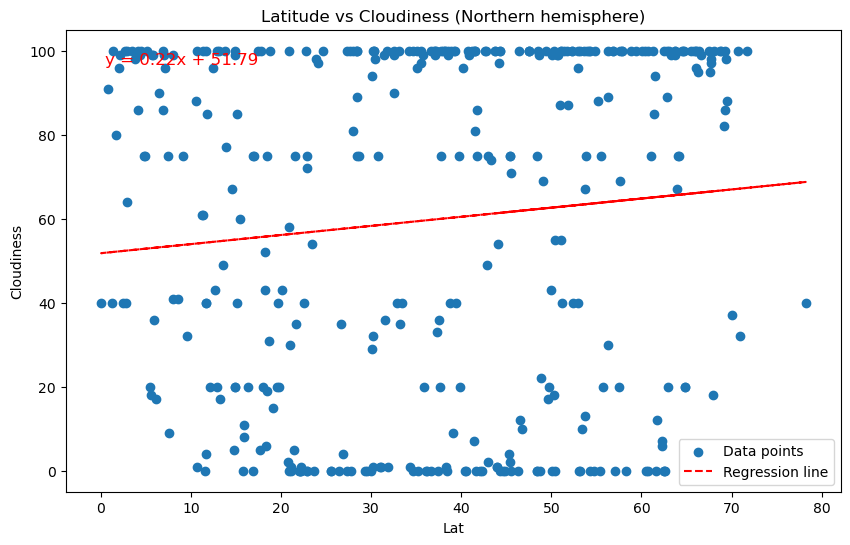

In [186]:
# Northern Hemisphere

plot_linear_regression(northern_hemi_df, "Lat", "Cloudiness", title = "Latitude vs Cloudiness (Northern hemisphere)")

LinregressResult(slope=1.5211968166224843, intercept=93.72945613649547, rvalue=0.5281030245321587, pvalue=3.204354933821394e-12, stderr=0.20038884103009688, intercept_stderr=5.178681109326517)


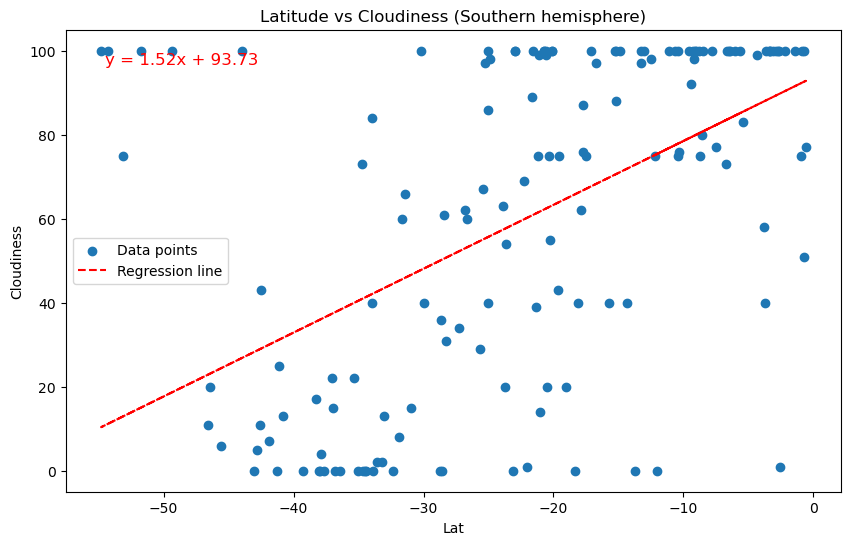

In [188]:
# Southern Hemisphere

plot_linear_regression(southern_hemi_df, "Lat", "Cloudiness", title = "Latitude vs Cloudiness (Southern hemisphere)")


**Discussion about the linear relationship:** Whereas there were no correlation of latitude to cloudiness in northern hemisphere (R=0.10), in southern hemisphere, it was positively correlated with R=0.53 with good association of pValues.

### Wind Speed vs. Latitude Linear Regression Plot

LinregressResult(slope=0.01499272107520229, intercept=3.363415242923026, rvalue=0.10375965723937838, pvalue=0.04551000791623148, stderr=0.0074713756683686995, intercept_stderr=0.3110276755445162)


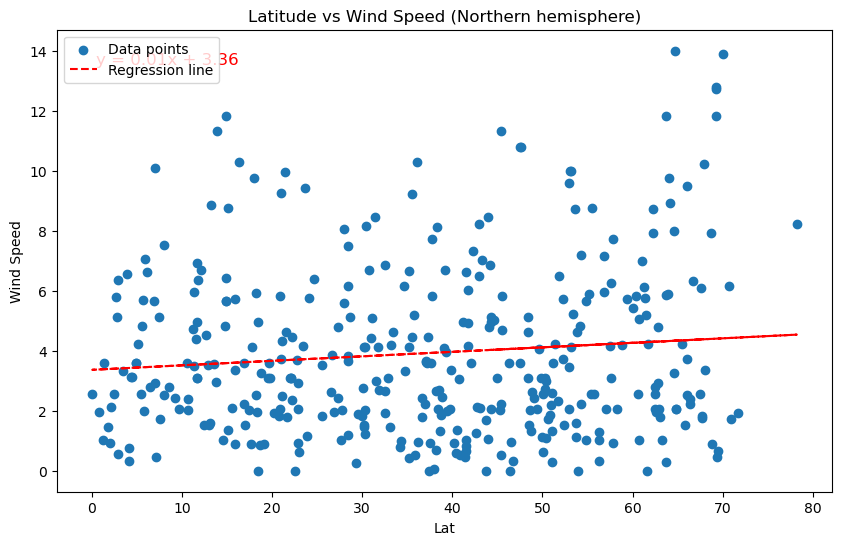

In [196]:
# Northern Hemisphere


plot_linear_regression(northern_hemi_df, "Lat", "Wind Speed", title = "Latitude vs Wind Speed (Northern hemisphere)")


LinregressResult(slope=-0.05650347525202407, intercept=2.252401121146924, rvalue=-0.29676681133851623, pvalue=0.00021548026856662547, stderr=0.014895233588484418, intercept_stderr=0.38493992183978243)


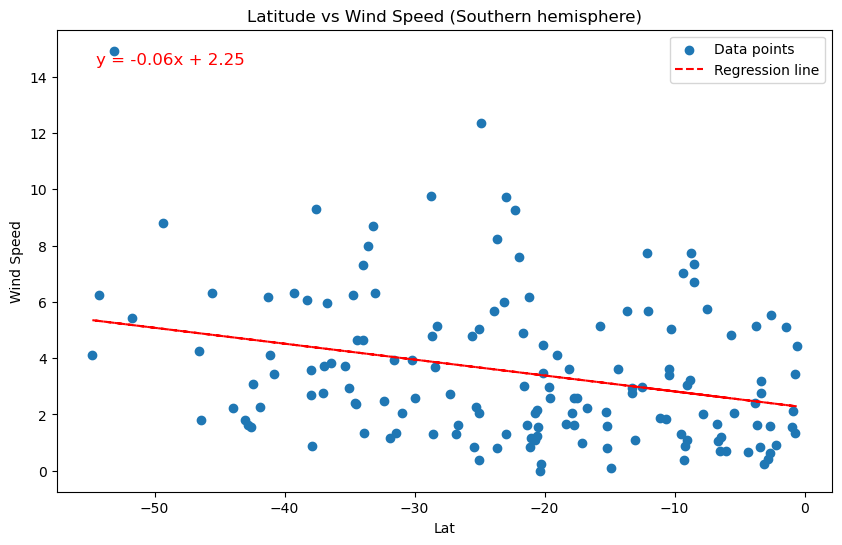

In [192]:
# Southern Hemisphere

plot_linear_regression(southern_hemi_df, "Lat", "Wind Speed", title = "Latitude vs Wind Speed (Southern hemisphere)")


**Discussion about the linear relationship:** No correlation of latitude to Wind Speed in northern hemisphere. Interestingly, we observed very slight negative corelation in southern hemisphere with R=-0.29.